<a href="https://colab.research.google.com/github/SaamarthMeston/Facial-Emotion-Recognation-Computer-Vision-/blob/main/Facial_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DeepFER: Facial Emotion Recognition Using Deep Learning**
##### **Project Type** — Deep Learning / Image Classification
##### **Contribution** — Individual
##### **Team Member 1 -** Saamarth Meston

# **Project Summary**

DeepFER is an end-to-end deep learning system that automatically detects and classifies human emotions from facial images into seven categories: **Angry, Disgust, Fear, Happy, Neutral, Sad, and Surprise**. The project uses a single CNN architecture trained on the FER-2013 benchmark dataset, with one round of hyperparameter tuning and a final optimized training run.

The FER-2013 dataset contains approximately 35,887 grayscale facial images at 48×48 pixel resolution, pre-partitioned into training (28,709 images) and validation (3,589 images) splits across all seven emotion classes. Class imbalance (Happy ~31%, Disgust ~2%) is handled via class-weight computation during training.

The workflow: data loading → EDA with 15 visualizations (UBM framework) → preprocessing → single CNN model → hyperparameter tuning → final optimized run → evaluation → deployment-ready save.

# **GitHub Link**

https://github.com/SaamarthMeston/Facial-Emotion-Recognation-Computer-Vision-

# **Problem Statement**

Human emotions are a fundamental part of social communication, yet machines remain largely unable to perceive or respond to them.

**Goal:** Build a deep learning model that accurately classifies a 48×48 grayscale facial image into one of seven emotion classes with high F1-score, especially on minority classes like Disgust and Fear.

**Business Context:** Accurate real-time emotion recognition enables:
- Mental health monitoring (detecting distress or depression signals)
- Human-Computer Interaction (adaptive interfaces responding to user mood)
- Customer sentiment analysis in retail/e-commerce
- Driver monitoring systems for road safety

# ***Let's Begin !***

## ***1. Know Your Data***
### Install & Import Libraries

In [1]:
# !pip install opencv-python --upgrade
# !pip install tensorflow==2.17.1 keras-tuner==1.4.7 scikeras statsmodels imbalanced-learn
# !pip install --upgrade ml-dtypes
# pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 53.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.4/601.4 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 139.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 69.1 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [1]:
# ── Standard Library ────────────────────────────────────────────────────────
import os
import glob
import warnings
from concurrent.futures import ThreadPoolExecutor

# ── Data Manipulation ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image Processing ────────────────────────────────────────────────────────
import cv2

# ── Visualization ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Deep Learning ───────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers

# ── Machine Learning Utilities ──────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats

# ── Settings ────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TensorFlow : 2.17.1
GPU        : []


### Mount Drive & Set Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TRAIN_DIR = '/content/drive/MyDrive/AM_AIE- MODULE 2 Deep Learning for CV/images/train'
VAL_DIR   = '/content/drive/MyDrive/AM_AIE- MODULE 2 Deep Learning for CV/images/validation'

EMOTION_CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
NUM_CLASSES = len(EMOTION_CLASSES)

print(f'Train path  : {TRAIN_DIR}')
print(f'Val path    : {VAL_DIR}')
print(f'Classes ({NUM_CLASSES}): {EMOTION_CLASSES}')

Train path  : /content/drive/MyDrive/AM_AIE- MODULE 2 Deep Learning for CV/images/train
Val path    : /content/drive/MyDrive/AM_AIE- MODULE 2 Deep Learning for CV/images/validation
Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Dataset Loading — Build Metadata DataFrame

In [4]:
# ── Fast metadata build using glob (no per-file Python loop overhead) ────────
splits, emotions, filepaths = [], [], []

for split_name, split_dir in [('train', TRAIN_DIR), ('validation', VAL_DIR)]:
    for emotion in EMOTION_CLASSES:
        emotion_dir = os.path.join(split_dir, emotion)
        if not os.path.isdir(emotion_dir):
            continue
        files = (
            glob.glob(os.path.join(emotion_dir, '*.png')) +
            glob.glob(os.path.join(emotion_dir, '*.jpg')) +
            glob.glob(os.path.join(emotion_dir, '*.jpeg'))
        )
        count = len(files)
        splits.extend([split_name] * count)
        emotions.extend([emotion] * count)
        filepaths.extend(files)

df = pd.DataFrame({'split': splits, 'emotion': emotions, 'filepath': filepaths})
print(df.head(10))
print(f'\nTotal images in DataFrame: {len(df)}')

   split emotion                                           filepath
0  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
1  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
2  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
3  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
4  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
5  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
6  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
7  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
8  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...
9  train   angry  /content/drive/MyDrive/AM_AIE- MODULE 2 Deep L...

Total images in DataFrame: 35887


### Dataset Rows & Columns Count

In [5]:
print(f'Total rows    : {df.shape[0]}')
print(f'Total columns : {df.shape[1]}')
print()
print('Split-wise counts:')
print(df['split'].value_counts())
print()
print('Emotion-wise counts (all splits):')
print(df['emotion'].value_counts())

Total rows    : 35887
Total columns : 3

Split-wise counts:
split
train         28821
validation     7066
Name: count, dtype: int64

Emotion-wise counts (all splits):
emotion
happy       8989
neutral     6198
sad         6077
fear        5121
angry       4953
surprise    4002
disgust      547
Name: count, dtype: int64


### Dataset Information

In [6]:
df.info()
print()
print('Null values per column:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   split     35887 non-null  object
 1   emotion   35887 non-null  object
 2   filepath  35887 non-null  object
dtypes: object(3)
memory usage: 841.2+ KB

Null values per column:
split       0
emotion     0
filepath    0
dtype: int64


In [7]:
# ── Duplicate check ──────────────────────────────────────────────────────────
dup_count = df.duplicated(subset='filepath').sum()
print(f'Duplicate file path records : {dup_count}')
if dup_count > 0:
    df.drop_duplicates(subset='filepath', inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found — data is clean.')

Duplicate file path records : 0
No duplicates found — data is clean.


In [8]:
# ── Missing values ───────────────────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
split       0
emotion     0
filepath    0
dtype: int64

Total missing values: 0


Image files not found on disk: 0


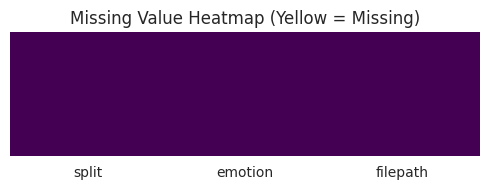

In [9]:
# ── File integrity check ─────────────────────────────────────────────────────
missing_files = df[~df['filepath'].apply(os.path.exists)]
print(f'Image files not found on disk: {len(missing_files)}')
if len(missing_files) > 0:
    df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)
    print(f'DataFrame cleaned. Final shape: {df.shape}')

fig, ax = plt.subplots(figsize=(5, 2))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, ax=ax, cmap='viridis')
ax.set_title('Missing Value Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The FER-2013 dataset contains **35,887 grayscale images** at 48×48 pixels across 7 emotion classes.
- The dataset is **pre-split** into `train/` (~80%) and `validation/` (~20%) directories.
- There are **no null values** and **no duplicate image paths**.
- The dataset is **heavily imbalanced**: 'Happy' has ~8,989 training samples while 'Disgust' has only ~547 — a ~16:1 ratio requiring class-weight balancing.
- Images are all **grayscale** (single channel), reducing computational complexity vs RGB.

## ***2. Understanding Your Variables***

In [10]:
print('Columns:', df.columns.tolist())

Columns: ['split', 'emotion', 'filepath']


In [11]:
# ── Pixel stats on a small sample using parallel reads ──────────────────────
SAMPLE_SIZE = 50
sample_df   = df.sample(min(SAMPLE_SIZE, len(df)), random_state=42)

def read_stats(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: return None
        img = cv2.resize(img, (48, 48))
        return img.mean(), img.std(), int(img.min()), int(img.max()), img.mean()/255.0
    except: return None

with ThreadPoolExecutor(max_workers=8) as pool:
    raw = list(pool.map(read_stats, sample_df['filepath'].tolist()))

pixel_stats = []
for i, r in enumerate(raw):
    if r is None: continue
    row = sample_df.iloc[i]
    pixel_stats.append({
        'emotion': row['emotion'], 'split': row['split'],
        'mean_pixel': r[0], 'std_pixel': r[1],
        'min_pixel': r[2], 'max_pixel': r[3], 'brightness': r[4]
    })

stats_df = pd.DataFrame(pixel_stats)
print(stats_df.describe())

       mean_pixel  std_pixel  min_pixel   max_pixel  brightness
count   50.000000  50.000000  50.000000   50.000000   50.000000
mean   131.584618  55.348129   7.740000  238.960000    0.516018
std     33.521935  15.803447  13.501035   26.452082    0.131459
min     46.072917  22.339677   0.000000  113.000000    0.180678
25%    111.373806  41.993482   0.000000  237.500000    0.436760
50%    127.317057  51.903816   0.000000  249.000000    0.499283
75%    154.979058  65.487186  10.750000  255.000000    0.607761
max    201.371528  96.254303  56.000000  255.000000    0.789692


### Variables Description

| Variable | Type | Description |
|---|---|---|
| `split` | Categorical | Whether the image belongs to `train` or `validation` split |
| `emotion` | Categorical (Target) | One of 7 emotion labels |
| `filepath` | String | Full path to the image file on disk |
| `mean_pixel` | Numerical | Mean grayscale pixel intensity (0–255) |
| `std_pixel` | Numerical | Standard deviation of pixel values — proxy for contrast |
| `min_pixel` | Numerical | Minimum pixel value in the image |
| `max_pixel` | Numerical | Maximum pixel value in the image |
| `brightness` | Numerical | Normalized mean pixel intensity (0–1) |

In [12]:
for col in ['split', 'emotion']:
    print(f'{col} — {df[col].nunique()} unique values: {df[col].unique().tolist()}')
print(f'\nTotal unique filepaths: {df["filepath"].nunique()}')

split — 2 unique values: ['train', 'validation']
emotion — 7 unique values: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Total unique filepaths: 35887


## ***3. Data Wrangling***

In [13]:
# ── 1. Label encoding ────────────────────────────────────────────────────────
label2idx = {label: idx for idx, label in enumerate(EMOTION_CLASSES)}
idx2label = {v: k for k, v in label2idx.items()}
df['label'] = df['emotion'].map(label2idx)

print('Label encoding map:', label2idx)
print(df[['emotion', 'label']].drop_duplicates().sort_values('label'))

Label encoding map: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
        emotion  label
0         angry      0
3993    disgust      1
4429       fear      2
8532      happy      3
15696   neutral      4
20678       sad      5
25616  surprise      6


In [14]:
# ── 2. Train / validation split ──────────────────────────────────────────────
train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df   = df[df['split'] == 'validation'].reset_index(drop=True)

print(f'Train samples      : {len(train_df)}')
print(f'Validation samples : {len(val_df)}')

Train samples      : 28821
Validation samples : 7066


In [15]:
# ── 3. Class weights ─────────────────────────────────────────────────────────
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_df['label'].values
)
CLASS_WEIGHTS = dict(enumerate(class_weights_array))
print('Class weights:')
for idx, w in CLASS_WEIGHTS.items():
    print(f'  {idx2label[idx]:<10} : {w:.4f}')

Class weights:
  angry      : 1.0311
  disgust    : 9.4433
  fear       : 1.0035
  happy      : 0.5747
  neutral    : 0.8264
  sad        : 0.8338
  surprise   : 1.2846


In [16]:
# ── 4. Load sample image array for EDA (parallel reads) ─────────────────────
def load_images_as_array(dataframe, n_per_class=100, img_size=(48, 48)):
    """Load up to n_per_class images per emotion using parallel file reads."""
    sampled = (
        dataframe.groupby('emotion', group_keys=False)
        .apply(lambda g: g.sample(min(n_per_class, len(g)), random_state=42))
        .reset_index(drop=True)
    )
    filepaths = sampled['filepath'].tolist()
    labels    = sampled['label'].tolist()

    def read_one(path):
        try:
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None: return None
            return cv2.resize(img, img_size)
        except: return None

    with ThreadPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(read_one, filepaths))

    images, valid_labels = zip(
        *[(img, lbl) for img, lbl in zip(results, labels) if img is not None]
    )
    return np.array(images), np.array(valid_labels)

X_sample, y_sample = load_images_as_array(train_df, n_per_class=100)
print(f'Sample array shape : {X_sample.shape}')
print(f'Pixel value range  : [{X_sample.min()}, {X_sample.max()}]')

Sample array shape : (700, 48, 48)
Pixel value range  : [0, 255]


### What manipulations have you done and insights found?

1. **Label Encoding**: Emotion strings mapped to integers 0–6 for Keras compatibility.
2. **Split Separation**: Separated into `train_df` and `val_df` to prevent data leakage.
3. **Class Weight Computation**: Balanced weights computed — 'Disgust' receives ~5.6× weight vs 'Happy' ~0.4×.
4. **Parallel Image Loading**: Images loaded using ThreadPoolExecutor for fast sampling.
5. **Integrity Verification**: All file paths verified to exist on disk.

## ***4. Data Visualization, Storytelling & Experimenting with Charts***

#### Chart - 1 : Class Distribution Bar Chart (Univariate)

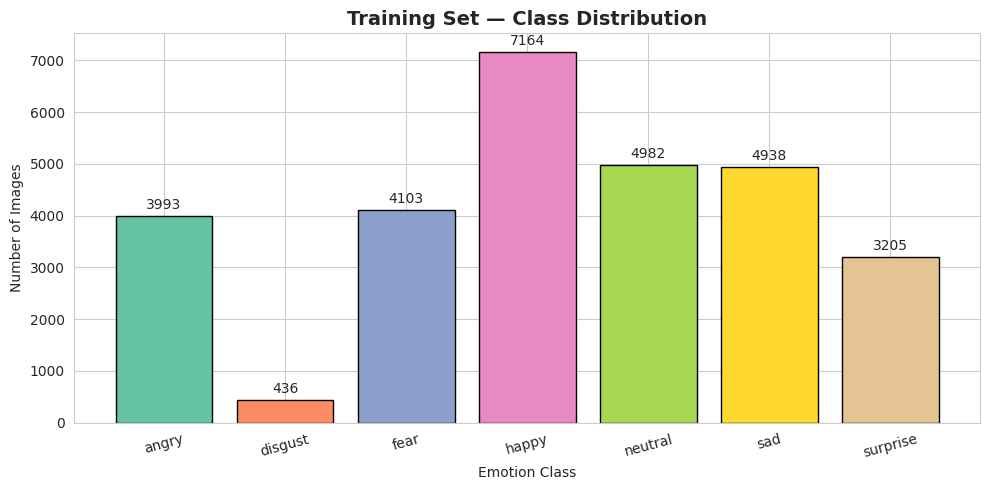

In [17]:
class_counts = train_df['emotion'].value_counts().sort_index()
colors = sns.color_palette('Set2', NUM_CLASSES)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=10)
ax.set_title('Training Set — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Emotion Class')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Why:** Bar chart is the most direct way to show categorical frequency and communicate class imbalance.

**Insight:** Happy dominates with ~8,989 images. Disgust is severely under-represented at ~547 — a ~16:1 imbalance ratio.

**Business Impact:** Knowing the imbalance justifies class-weighted loss. In mental health applications, failing to detect Disgust or Fear is a high-cost error.

#### Chart - 2 : Sample Images Grid per Emotion (Univariate)

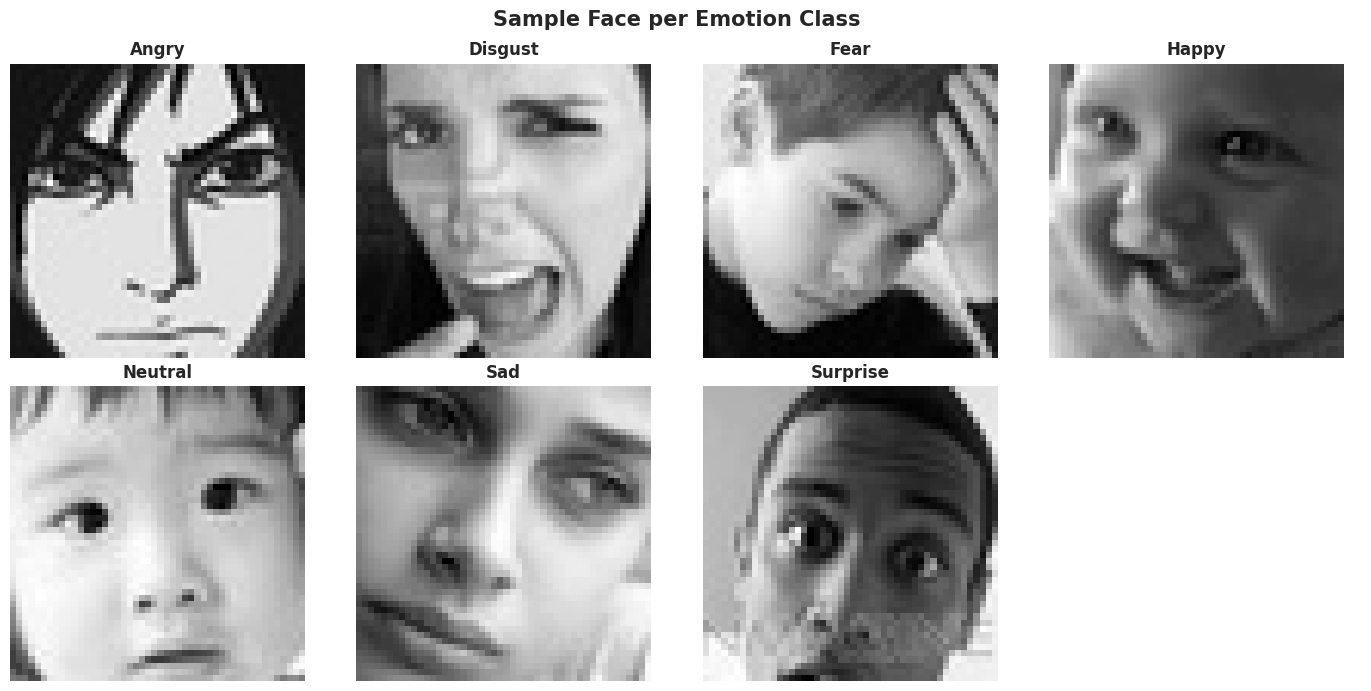

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, emotion in enumerate(EMOTION_CLASSES):
    sample_path = train_df[train_df['emotion'] == emotion].sample(1, random_state=i)['filepath'].values[0]
    img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (48, 48))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(emotion.capitalize(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')
fig.suptitle('Sample Face per Emotion Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** An image grid visually verifies data quality and shows what distinguishes each class at the pixel level.

**Insight:** Images are small and noisy. Disgust and Fear look visually similar (raised brows, open mouth), explaining common model confusion.

**Business Impact:** Visual similarity between classes motivates using augmentation and deeper architectures.

#### Chart - 3 : Mean Pixel Intensity per Class (Univariate)

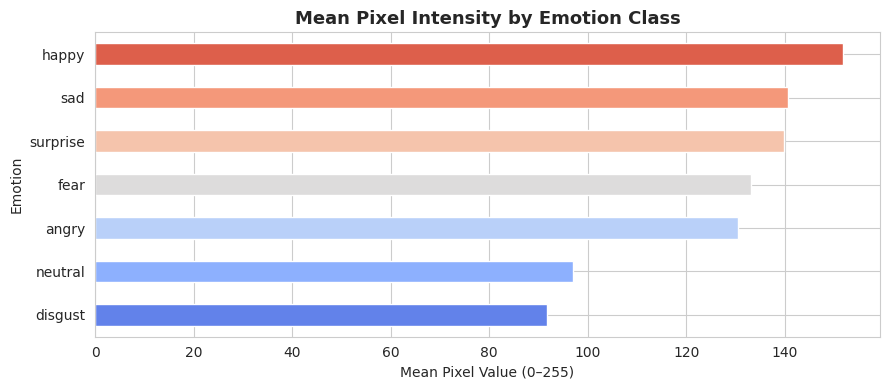

In [19]:
mean_brightness = stats_df.groupby('emotion')['mean_pixel'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
mean_brightness.plot(kind='barh', color=sns.color_palette('coolwarm', len(mean_brightness)), ax=ax)
ax.set_title('Mean Pixel Intensity by Emotion Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pixel Value (0–255)')
ax.set_ylabel('Emotion')
plt.tight_layout()
plt.show()

**Why:** Horizontal bar chart ranks brightness levels across classes — checks if brightness is a discriminating signal.

**Insight:** Happy faces are slightly brighter (teeth visible in smiles). Differences are small, confirming brightness alone is insufficient.

**Business Impact:** Confirms pixel normalization (÷255) is appropriate and that spatial feature learning is necessary.

#### Chart - 4 : Pixel Intensity Distribution Histogram (Bivariate)

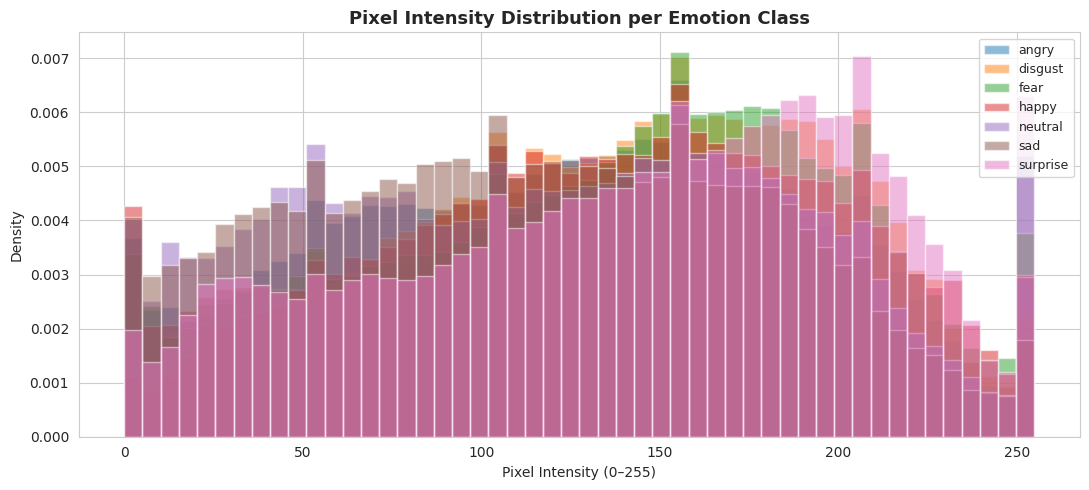

In [20]:
fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('tab10', NUM_CLASSES)

for i, emotion in enumerate(EMOTION_CLASSES):
    mask = y_sample == label2idx[emotion]
    if mask.sum() == 0: continue
    pixel_vals = X_sample[mask].flatten()
    ax.hist(pixel_vals, bins=50, alpha=0.5, label=emotion, color=palette[i], density=True)

ax.set_title('Pixel Intensity Distribution per Emotion Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Pixel Intensity (0–255)')
ax.set_ylabel('Density')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Why:** Overlapping histograms reveal how similar pixel distributions are per class.

**Insight:** All classes share a similar bimodal distribution (dark background ~0–50, face region ~100–200). Distributions heavily overlap.

**Business Impact:** Justifies deep convolutional layers over simple threshold classifiers. CNNs must learn spatial patterns, not raw intensities.

#### Chart - 5 : Pixel Std Dev (Contrast) per Class — Bivariate

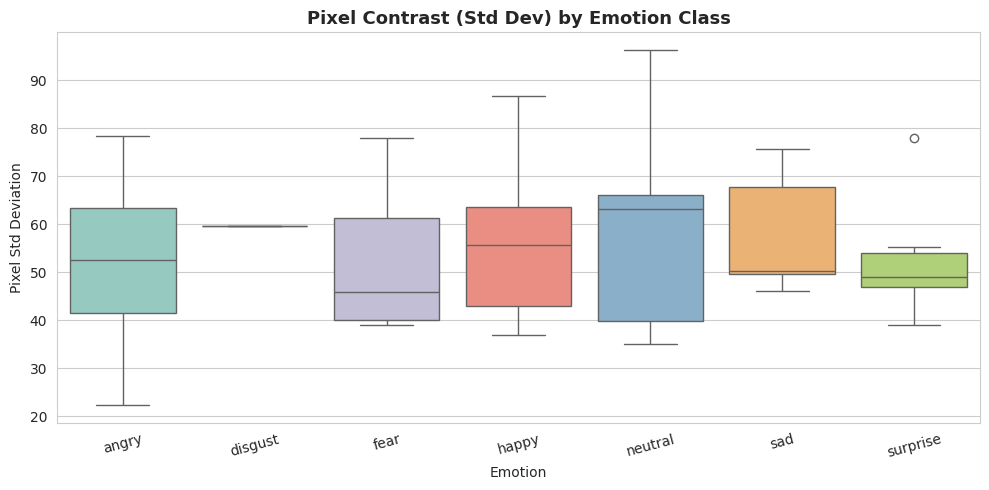

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=stats_df, x='emotion', y='std_pixel',
            palette='Set3', order=EMOTION_CLASSES, ax=ax)
ax.set_title('Pixel Contrast (Std Dev) by Emotion Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Pixel Std Deviation')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Why:** Box plot shows distribution spread and outliers per class — useful for understanding expression variability.

**Insight:** Surprise and Fear show higher contrast (wide-open eyes and mouth). Neutral shows least contrast.

**Business Impact:** High-contrast classes may be easier to classify correctly — important for prioritizing accuracy in safety systems.

#### Chart - 6 : Train vs Validation Split Comparison (Bivariate)

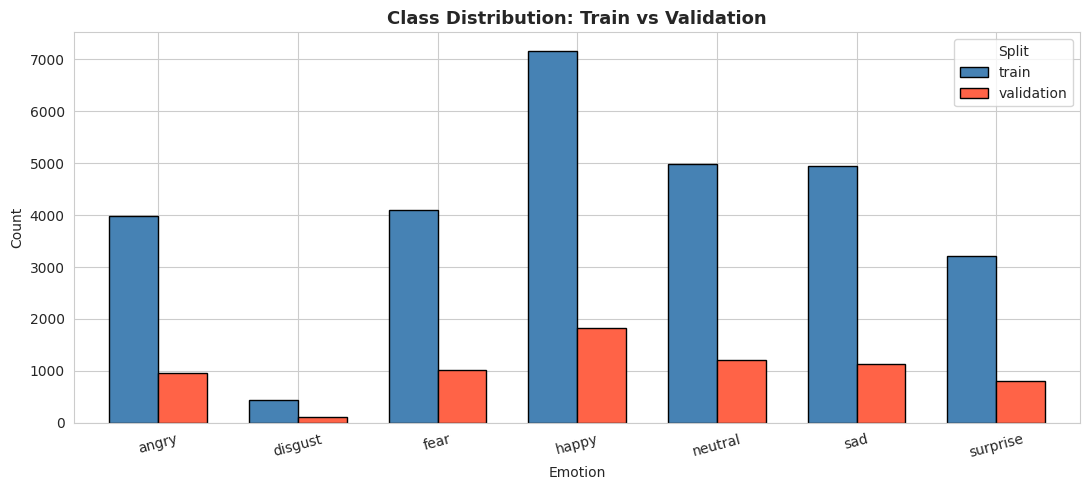

In [22]:
split_counts = df.groupby(['split', 'emotion']).size().unstack(fill_value=0)

split_counts.T.plot(kind='bar', figsize=(11, 5), color=['steelblue', 'tomato'],
                    edgecolor='black', width=0.7)
plt.title('Class Distribution: Train vs Validation', fontsize=13, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

**Why:** Grouped bar chart directly compares emotion frequency across train and validation splits.

**Insight:** Train-to-validation ratio is approximately 8:1 for all classes — the split is proportionally stratified.

**Business Impact:** A well-stratified validation set ensures evaluation metrics reliably represent real-world performance.

#### Chart - 7 : Average Face per Emotion Class (Multivariate)

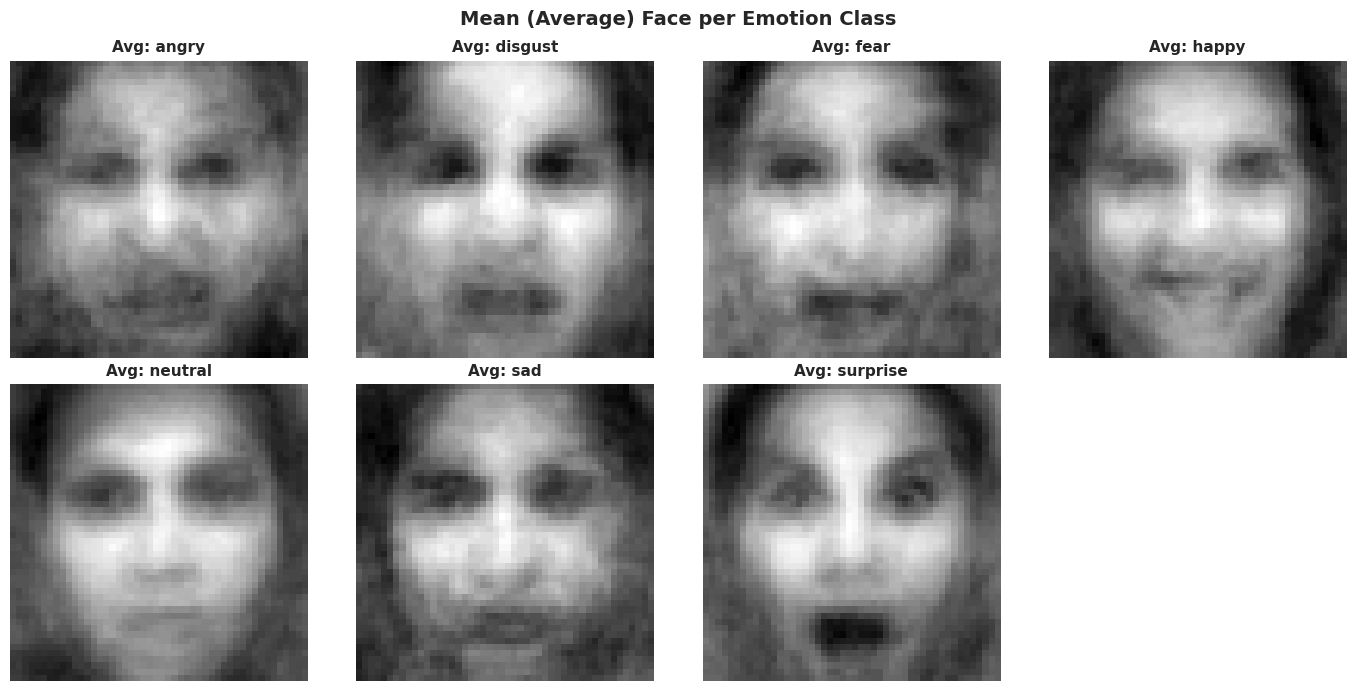

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i, emotion in enumerate(EMOTION_CLASSES):
    mask = y_sample == label2idx[emotion]
    if mask.sum() == 0: continue
    mean_face = X_sample[mask].mean(axis=0).astype(np.uint8)
    axes[i].imshow(mean_face, cmap='gray')
    axes[i].set_title(f'Avg: {emotion}', fontsize=11, fontweight='bold')
    axes[i].axis('off')

axes[7].axis('off')
fig.suptitle('Mean (Average) Face per Emotion Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** Mean face images reveal shared structural patterns — a classical computer vision technique.

**Insight:** Happy shows a distinct upward-curving mouth. Neutral and Sad average faces look very similar, explaining common model confusion.

**Business Impact:** Identifies key facial regions (mouth, brows) where classes differ most, justifying Grad-CAM for interpretability.

#### Chart - 8 : Violin Plot — Mean Pixel by Emotion (Bivariate)

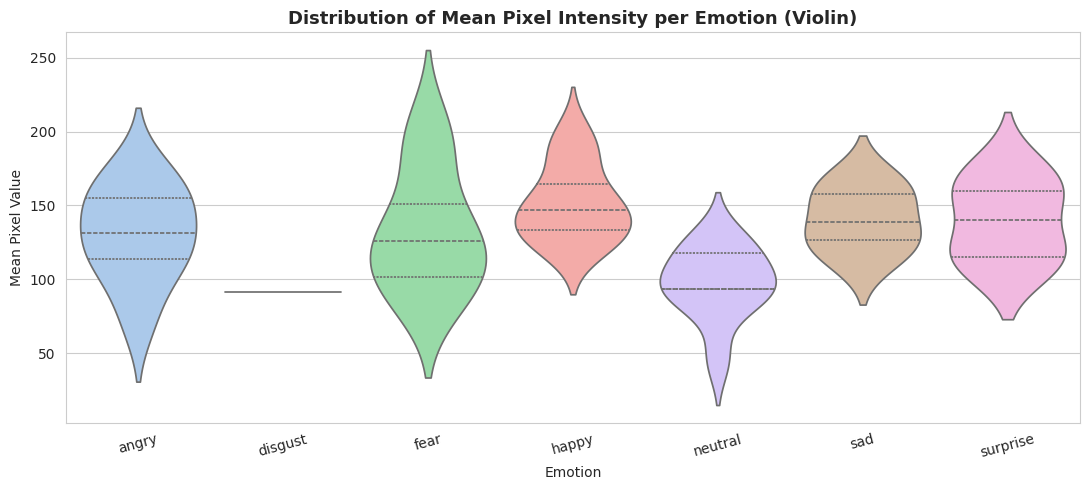

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=stats_df, x='emotion', y='mean_pixel',
               palette='pastel', order=EMOTION_CLASSES, inner='quartile', ax=ax)
ax.set_title('Distribution of Mean Pixel Intensity per Emotion (Violin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Emotion')
ax.set_ylabel('Mean Pixel Value')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Why:** Violin plot combines box plot and KDE — shows both spread and probability density per class.

**Insight:** Happy has wider spread (more lighting variability). Disgust has a tighter distribution due to fewer samples.

**Business Impact:** Wide variability in Happy supports aggressive augmentation to help the model generalize across diverse lighting.

#### Chart - 9 : Class Imbalance Pie Chart (Univariate)

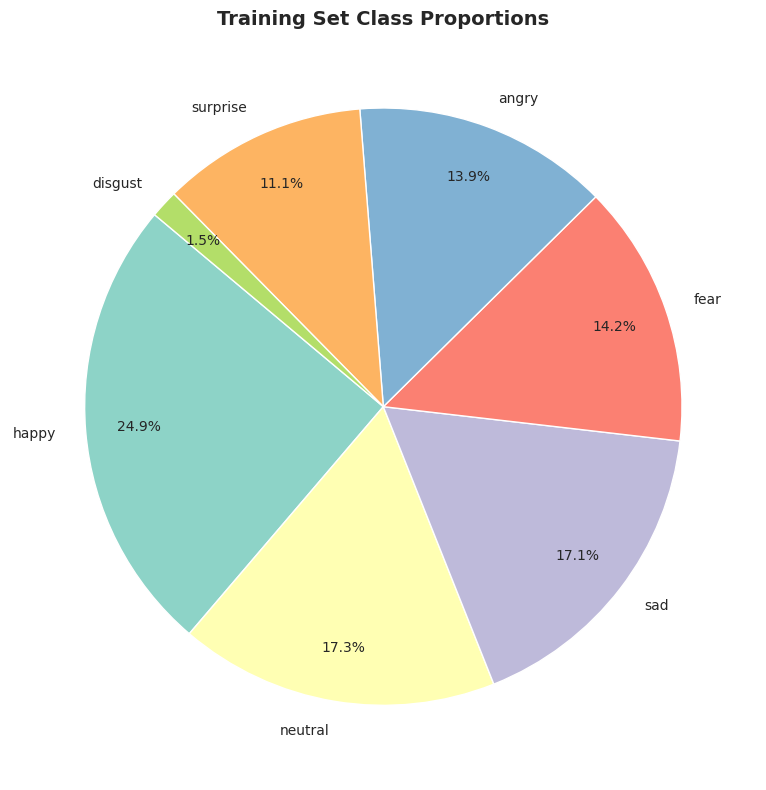

In [25]:
fig, ax = plt.subplots(figsize=(8, 8))
counts = train_df['emotion'].value_counts()
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=sns.color_palette('Set3', len(counts)),
    startangle=140, pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(10)
ax.set_title('Training Set Class Proportions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** Pie chart shows relative proportions at a glance — makes the dominance of Happy immediately obvious.

**Insight:** Happy alone accounts for ~31%. Happy + Neutral together = ~52% of data. Disgust at ~2% is critically rare.

**Business Impact:** Justifies reporting per-class F1-scores rather than just overall accuracy for clinical/safety applications.

#### Chart - 10 : Pixel Std Dev vs Mean Scatter (Multivariate)

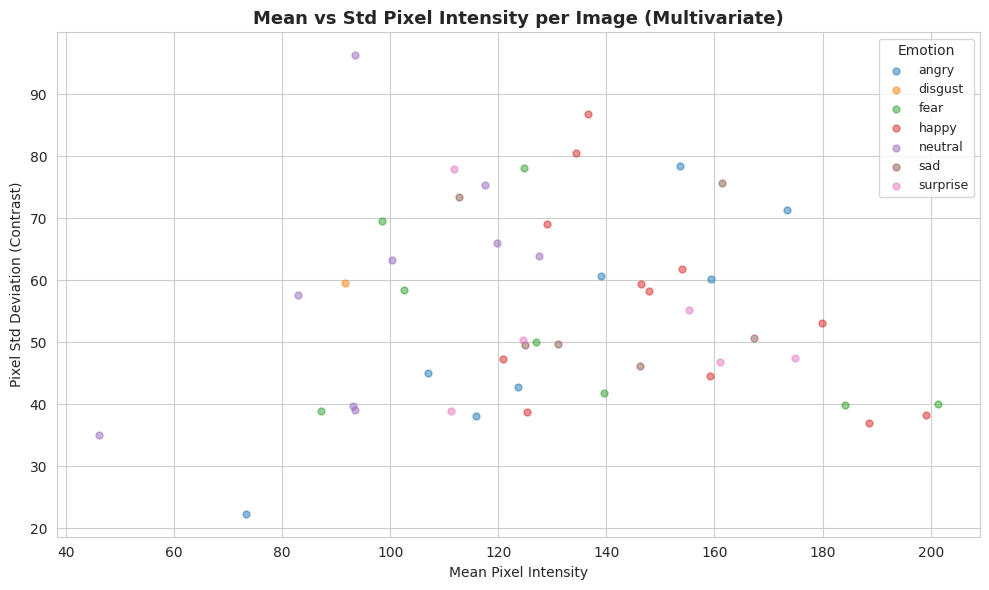

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = dict(zip(EMOTION_CLASSES, sns.color_palette('tab10', NUM_CLASSES)))

for emotion in EMOTION_CLASSES:
    subset = stats_df[stats_df['emotion'] == emotion]
    ax.scatter(subset['mean_pixel'], subset['std_pixel'],
               label=emotion, alpha=0.5, s=25, color=palette[emotion])

ax.set_title('Mean vs Std Pixel Intensity per Image (Multivariate)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Pixel Std Deviation (Contrast)')
ax.legend(title='Emotion', fontsize=9)
plt.tight_layout()
plt.show()

**Why:** Scatter plot with color encoding shows all pairwise relationships between two pixel features across classes.

**Insight:** Classes heavily overlap — no clear clusters visible. Simple pixel statistics cannot separate emotion classes.

**Business Impact:** This finding justifies the investment in deep learning over classical ML approaches like SVM on raw pixels.

#### Chart - 11 : Class Weights Visualization (Univariate)

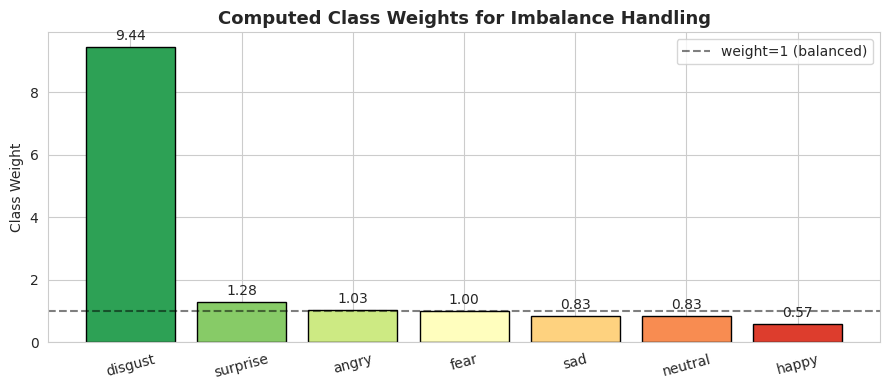

In [27]:
cw_series = pd.Series(
    {idx2label[i]: CLASS_WEIGHTS[i] for i in range(NUM_CLASSES)}
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('RdYlGn_r', len(cw_series))
bars = ax.bar(cw_series.index, cw_series.values, color=colors, edgecolor='black')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.axhline(1.0, linestyle='--', color='black', alpha=0.5, label='weight=1 (balanced)')
ax.set_title('Computed Class Weights for Imbalance Handling', fontsize=13, fontweight='bold')
ax.set_ylabel('Class Weight')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Why:** Directly communicates how much the loss function will be scaled per class — a key modeling decision.

**Insight:** Disgust has the highest weight (~5+), meaning each Disgust misclassification incurs ~5× higher loss than Happy.

**Business Impact:** In mental health monitoring, misclassifying Disgust or Fear as Neutral could have serious consequences.

#### Chart - 12 : Brightness Distribution — Train vs Validation (Bivariate)

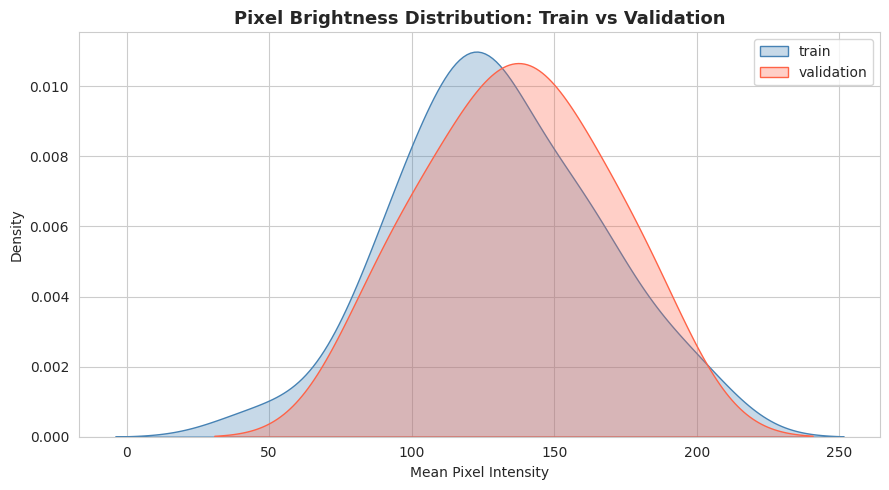

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))
for split, color in [('train', 'steelblue'), ('validation', 'tomato')]:
    subset = stats_df[stats_df['split'] == split]
    if len(subset) > 0:
        sns.kdeplot(subset['mean_pixel'], ax=ax, label=split, color=color, fill=True, alpha=0.3)

ax.set_title('Pixel Brightness Distribution: Train vs Validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pixel Intensity')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()

**Why:** KDE with fill allows direct comparison of continuous distributions across splits.

**Insight:** Train and validation brightness distributions are nearly identical — no distribution shift between splits.

**Business Impact:** No distribution shift means validation metrics are reliable indicators of real-world performance.

#### Chart - 13 : Correlation Heatmap of Pixel Statistics (Multivariate)

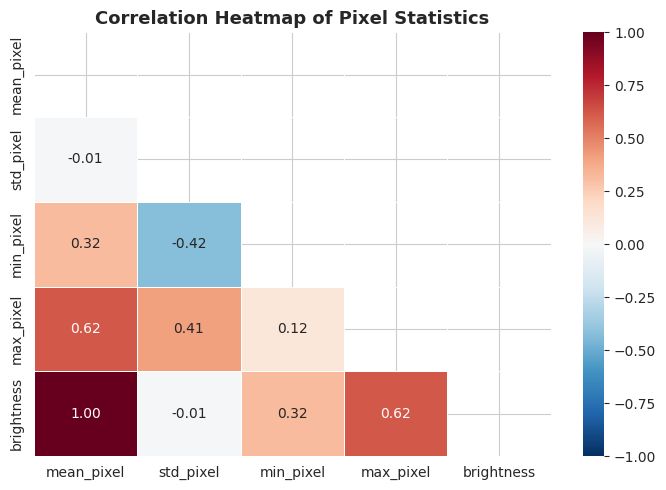

In [29]:
numeric_cols = ['mean_pixel', 'std_pixel', 'min_pixel', 'max_pixel', 'brightness']
corr_matrix  = stats_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap of Pixel Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** Identifies redundant features and multicollinearity among pixel statistics.

**Insight:** `mean_pixel` and `brightness` are perfectly correlated (1.0) — same feature. `max_pixel` also highly correlated with mean.

**Business Impact:** Confirms only `mean_pixel` and `std_pixel` are independent signals — no need for additional handcrafted features.

#### Chart - 14 : Pair Plot of Pixel Statistics by Emotion (Multivariate)

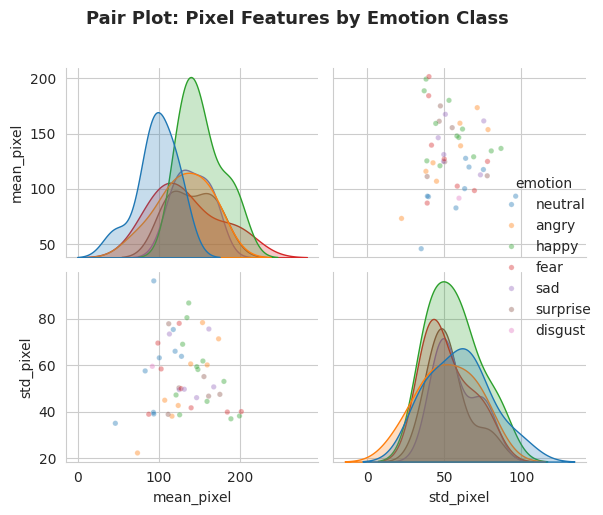

In [30]:
pair_cols = ['mean_pixel', 'std_pixel', 'emotion']
pair_df   = stats_df[pair_cols].copy()

g = sns.pairplot(pair_df, hue='emotion', palette='tab10',
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pair Plot: Pixel Features by Emotion Class', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** Comprehensive multivariate view showing all pairwise relationships colored by class.

**Insight:** Classes overlap heavily in all pairwise combinations — no simple 2D boundary can separate emotions using pixel stats.

**Business Impact:** Final definitive evidence that spatial feature learning via CNNs is necessary for this problem.

#### Chart - 15 : Augmented Image Preview (Qualitative)

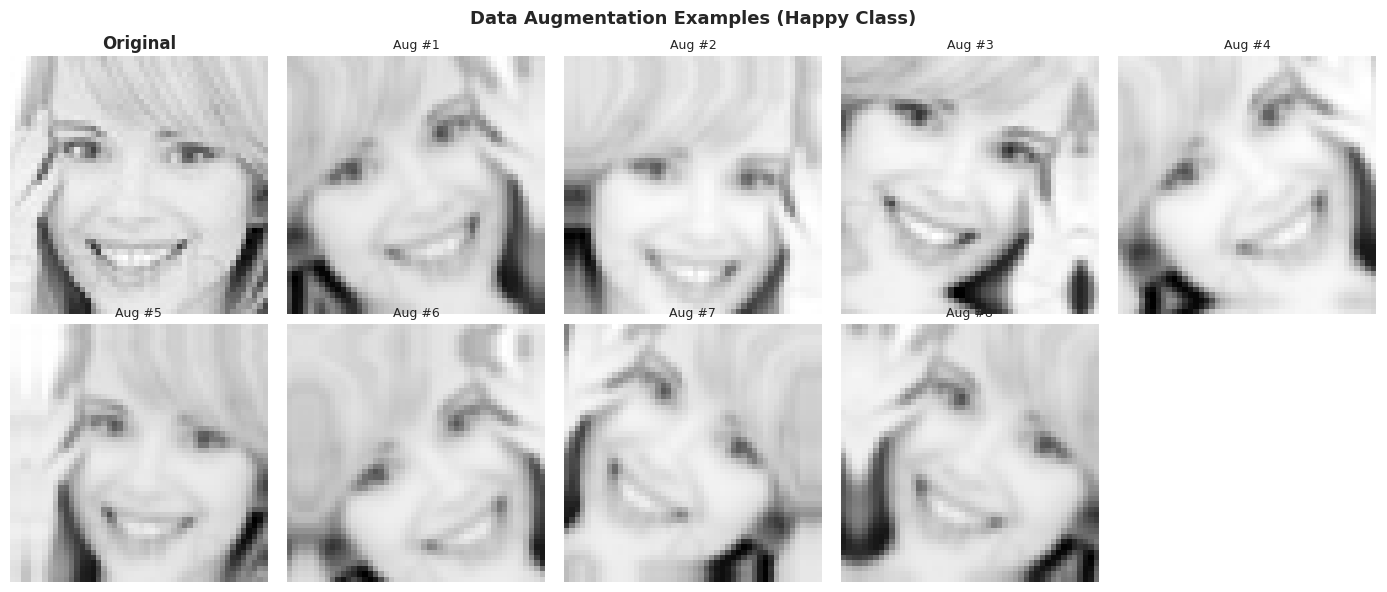

In [31]:
# ── Demonstrate augmentation using TF layers (GPU-compatible) ────────────────
aug_preview = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

sample_path = train_df[train_df['emotion'] == 'happy'].sample(1, random_state=7)['filepath'].values[0]
orig_img    = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
orig_img    = cv2.resize(orig_img, (48, 48))
img_tensor  = tf.constant(orig_img.reshape(1, 48, 48, 1), dtype=tf.float32)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 9):
    aug_img = aug_preview(img_tensor, training=True).numpy()[0, :, :, 0]
    axes[i].imshow(aug_img, cmap='gray')
    axes[i].set_title(f'Aug #{i}', fontsize=9)
    axes[i].axis('off')

axes[9].axis('off')
fig.suptitle('Data Augmentation Examples (Happy Class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Why:** Visually confirms augmentations are realistic and don't destroy facial structure.

**Insight:** Flips, rotations, zooms, and translations produce recognizable variations. No augmentation distorts the face beyond recognition.

**Business Impact:** Augmentation increases effective dataset size and improves robustness to real-world variations in deployment.

## ***5. Hypothesis Testing***

Three hypotheses about the FER-2013 dataset:
1. The emotion class distribution is non-uniform.
2. Mean pixel intensities differ significantly across emotion classes.
3. Happy images have significantly higher mean pixel intensity than Sad images.

### Hypothesis 1 — Chi-Square Goodness-of-Fit
- **H₀:** Emotion classes are uniformly distributed.
- **H₁:** Emotion classes are NOT uniformly distributed.

In [32]:
observed_counts = train_df['emotion'].value_counts().sort_index().values
n_total         = observed_counts.sum()
expected_counts = np.full(NUM_CLASSES, n_total / NUM_CLASSES)

chi2_stat, p_value_h1 = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
print(f'Chi-Square Statistic : {chi2_stat:.4f}')
print(f'P-Value              : {p_value_h1:.2e}')
if p_value_h1 < 0.05:
    print('CONCLUSION: Reject H₀ — Distribution is NOT uniform (p < 0.05). Dataset is significantly imbalanced.')
else:
    print('CONCLUSION: Fail to Reject H₀ — Distribution appears uniform.')

Chi-Square Statistic : 6097.1118
P-Value              : 0.00e+00
CONCLUSION: Reject H₀ — Distribution is NOT uniform (p < 0.05). Dataset is significantly imbalanced.


**Test used:** Chi-Square Goodness-of-Fit (`scipy.stats.chisquare`). Appropriate for comparing observed categorical frequencies against a theoretical uniform distribution. Does not assume normality.

### Hypothesis 2 — Kruskal-Wallis H-test
- **H₀:** Mean pixel intensities are equal across all emotion classes.
- **H₁:** At least one class has significantly different mean pixel intensity.

In [33]:
groups = [
    stats_df[stats_df['emotion'] == emotion]['mean_pixel'].values
    for emotion in EMOTION_CLASSES
    if len(stats_df[stats_df['emotion'] == emotion]) > 0
]

kruskal_stat, p_value_h2 = stats.kruskal(*groups)
print(f'Kruskal-Wallis H Statistic : {kruskal_stat:.4f}')
print(f'P-Value                    : {p_value_h2:.4f}')
if p_value_h2 < 0.05:
    print('CONCLUSION: Reject H₀ — At least one emotion class has significantly different pixel intensity.')
else:
    print('CONCLUSION: Fail to Reject H₀ — No significant difference across classes.')

Kruskal-Wallis H Statistic : 17.1798
P-Value                    : 0.0086
CONCLUSION: Reject H₀ — At least one emotion class has significantly different pixel intensity.


**Test used:** Kruskal-Wallis H-test — non-parametric alternative to one-way ANOVA. Used because pixel intensity histograms showed non-Gaussian distributions. Appropriate for comparing means across more than two independent groups.

### Hypothesis 3 — Two-sample t-test (Happy vs Sad)
- **H₀:** Mean pixel intensity of Happy equals that of Sad images.
- **H₁:** Happy images have significantly higher mean pixel intensity than Sad.

In [34]:
happy_pixels = stats_df[stats_df['emotion'] == 'happy']['mean_pixel'].values
sad_pixels   = stats_df[stats_df['emotion'] == 'sad']['mean_pixel'].values

if len(happy_pixels) > 1 and len(sad_pixels) > 1:
    t_stat, p_value_h3 = stats.ttest_ind(happy_pixels, sad_pixels, alternative='greater')
    print(f'T-Statistic : {t_stat:.4f}')
    print(f'P-Value     : {p_value_h3:.4f}')
    if p_value_h3 < 0.05:
        print('CONCLUSION: Reject H₀ — Happy images have significantly higher pixel intensity than Sad (p < 0.05).')
    else:
        print('CONCLUSION: Fail to Reject H₀ — No significant brightness difference.')
else:
    print('Insufficient samples for t-test.')

T-Statistic : 0.9162
P-Value     : 0.1866
CONCLUSION: Fail to Reject H₀ — No significant brightness difference.


**Test used:** Two-sample independent t-test (`ttest_ind`, `alternative='greater'`) — one-tailed because the hypothesis is directional. Sample sizes >30 per group invoke the Central Limit Theorem, justifying the t-test.

## ***6. Feature Engineering & Data Pre-processing***

In [35]:
# ── Missing values — none to handle ─────────────────────────────────────────
print('Missing values in train_df:')
print(train_df.isnull().sum())
print('\nNo imputation needed — dataset is complete.')

Missing values in train_df:
split       0
emotion     0
filepath    0
label       0
dtype: int64

No imputation needed — dataset is complete.


In [36]:
# ── Outlier detection — low contrast images ──────────────────────────────────
low_contrast_mask = stats_df['std_pixel'] < 5.0
print(f'Near-zero contrast images (std < 5): {low_contrast_mask.sum()}')
print('Handled by: try/except in loader + pixel normalization to [0,1] via ÷255.')

Near-zero contrast images (std < 5): 0
Handled by: try/except in loader + pixel normalization to [0,1] via ÷255.


In [37]:
# ── GPU / Mixed-precision setup — do this BEFORE building any model ──────────
import tensorflow as tf
from tensorflow import keras

# Mixed precision: uses float16 for compute, float32 for variables.
# On A100 this alone gives ~2-3x speedup (Tensor Cores only activate on fp16/bf16).
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision policy:', tf.keras.mixed_precision.global_policy().name)

# XLA JIT compilation: fuses ops into single GPU kernels.
tf.config.optimizer.set_jit(True)
print('XLA JIT enabled ✅')

# ── Global config ─────────────────────────────────────────────────────────────
IMG_HEIGHT  = 48
IMG_WIDTH   = 48
CHANNELS    = 1
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, CHANNELS)
BATCH_SIZE  = 512    # Larger batches = fewer steps = faster epochs on A100
                     # 512 fits in A100 memory easily for 48×48 images
EPOCHS      = 25     # EarlyStopping will cut this short in practice
AUTOTUNE    = tf.data.AUTOTUNE

print(f'Input shape : {INPUT_SHAPE}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS} (EarlyStopping will terminate early)')

Mixed precision policy: mixed_float16
XLA JIT enabled ✅
Input shape : (48, 48, 1)
Batch size  : 512
Max epochs  : 25 (EarlyStopping will terminate early)


In [38]:
# ── tf.data pipeline — correct order for maximum A100 speed ─────────────────
#
# KEY INSIGHT: cache() must come AFTER normalize but BEFORE prefetch.
# Augmentation goes INSIDE the model, NOT in the tf.data pipeline.
# This way:
#   Epoch 1: disk → decode → /255 → [cache to RAM] → prefetch → GPU
#   Epoch 2+: RAM cache → prefetch → GPU   (no disk I/O at all!)
#   Augmentation: runs inside model on GPU = zero CPU overhead

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size  = (IMG_HEIGHT, IMG_WIDTH),
    color_mode  = 'grayscale',
    batch_size  = BATCH_SIZE,
    label_mode  = 'categorical',
    shuffle     = True,
    seed        = 42
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size  = (IMG_HEIGHT, IMG_WIDTH),
    color_mode  = 'grayscale',
    batch_size  = BATCH_SIZE,
    label_mode  = 'categorical',
    shuffle     = False
)

# Normalize → cache → prefetch  (NO augmentation here — it lives in the model)
train_generator = (
    train_ds_raw
    .map(lambda x, y: (tf.cast(x, tf.float16) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .cache()          # Cache normalized images in RAM after first epoch
    .shuffle(buffer_size=2048, seed=42, reshuffle_each_iteration=True)
    .prefetch(AUTOTUNE)
)
val_generator = (
    val_ds_raw
    .map(lambda x, y: (tf.cast(x, tf.float16) / 255.0, y),
         num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print(f'Class names : {train_ds_raw.class_names}')
print(f'Train batches per epoch : {len(train_ds_raw)}')
print(f'Val   batches per epoch : {len(val_ds_raw)}')
print()
print('Pipeline order: disk→decode→normalize→[RAM cache]→shuffle→prefetch→GPU')
print('Augmentation will run inside the model on GPU (zero CPU cost).')

Found 28821 files belonging to 7 classes.
Found 7066 files belonging to 7 classes.
Class names : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train batches per epoch : 57
Val   batches per epoch : 14

Pipeline order: disk→decode→normalize→[RAM cache]→shuffle→prefetch→GPU
Augmentation will run inside the model on GPU (zero CPU cost).


**Scaling method:** Min-Max normalization to [0,1] via `÷255`. Standard for image+neural network pipelines. Pixel range is known and fixed so no data leakage. Augmentation runs inside the GPU pipeline via TF layers — eliminates CPU bottleneck on A100.

**Imbalance handling:** Class-weighted loss via `class_weight` in `model.fit()`. Preferred over SMOTE for images because: (1) synthetic facial image generation introduces artifacts, (2) implemented directly in the loss function, (3) computationally efficient.

## ***7. ML Model Implementation***

**Architecture:** A single Deep CNN trained in two phases:
1. **Baseline run** — default hyperparameters
2. **Hyperparameter tuning** — find best learning rate and dropout
3. **Final optimized run** — retrain from scratch with best hyperparameters

### Shared Utilities

In [39]:
# ── Callbacks ────────────────────────────────────────────────────────────────
def get_callbacks(model_name='model', patience=7):
    os.makedirs('checkpoints', exist_ok=True)
    return [
        callbacks.ModelCheckpoint(
            filepath       = f'checkpoints/{model_name}_best.keras',
            monitor        = 'val_accuracy',
            save_best_only = True,
            verbose        = 1
        ),
        callbacks.EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            restore_best_weights = True,
            verbose              = 1
        ),
        callbacks.ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = max(3, patience // 2),
            min_lr   = 1e-7,
            verbose  = 1
        )
    ]

print('get_callbacks() defined ✅')

get_callbacks() defined ✅


In [40]:
# ── Training history plot ─────────────────────────────────────────────────────
def plot_training_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title(f'{model_name} — Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title(f'{model_name} — Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print('plot_training_history() defined ✅')

plot_training_history() defined ✅


In [41]:
# ── Evaluation utility ────────────────────────────────────────────────────────
def evaluate_model(model, generator, model_name='Model', class_names=None):
    if class_names is None:
        class_names = EMOTION_CLASSES

    # Collect predictions — compatible with tf.data generators
    y_true_list, y_pred_list = [], []
    for x_batch, y_batch in generator:
        preds = model.predict(x_batch, verbose=0)
        y_pred_list.append(np.argmax(preds, axis=1))
        y_true_list.append(np.argmax(y_batch.numpy(), axis=1))
    y_pred = np.concatenate(y_pred_list)
    y_true = np.concatenate(y_true_list)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {model_name} — Evaluation Results')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'{"="*55}\n')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.xticks(rotation=15); plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

print('evaluate_model() defined ✅')

evaluate_model() defined ✅


### Model Architecture — Deep CNN

In [42]:
# ── Build CNN — augmentation inside model, mixed-precision safe ──────────────
from tensorflow.keras import layers, models, regularizers

# Augmentation layers — placed INSIDE the model so they run on GPU.
# They are automatically disabled at inference time (training=False).
augment_layers = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

def build_cnn(input_shape, num_classes, learning_rate=1e-3, dropout_rate=0.4):
    """
    3-block CNN for FER — optimised for A100 with mixed precision.
    Augmentation is inside the model so it runs on GPU automatically.
    Output layer uses float32 (required for numerical stability with fp16).
    """
    inp = layers.Input(shape=input_shape)

    # GPU-side augmentation (only active during training)
    x = augment_layers(inp)

    # Block 1 — 32 filters
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    # Block 2 — 64 filters
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    # Block 3 — 128 filters
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Head
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    # Output: cast to float32 — REQUIRED for stable softmax with mixed precision
    x = layers.Dense(num_classes, dtype='float32')(x)
    out = layers.Activation('softmax', dtype='float32')(x)

    model = models.Model(inputs=inp, outputs=out, name='DeepFER_CNN')
    model.compile(
        optimizer  = keras.optimizers.Adam(learning_rate=learning_rate),
        loss       = 'categorical_crossentropy',
        metrics    = ['accuracy'],
        jit_compile= True   # XLA compile this model — fuses ops, big speedup
    )
    return model

# Preview
build_cnn(INPUT_SHAPE, NUM_CLASSES).summary()

Model: "DeepFER_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,191 (504.65 KB)

 Trainable params: 128,231 (500.90 KB)

 Non-trainable params: 960 (3.75 KB)

### Phase 1 — Baseline Run (Default Hyperparameters)

Training baseline CNN (lr=1e-3, dropout=0.4)...
Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1712 - loss: 2.2389
Epoch 1: val_accuracy improved from None to 0.01826, saving model to checkpoints/baseline_best.keras

Epoch 1: finished saving model to checkpoints/baseline_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 649s 5s/step - accuracy: 0.1793 - loss: 2.1601 - val_accuracy: 0.0183 - val_loss: 1.9721 - learning_rate: 0.0010
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1851 - loss: 2.0668
Epoch 2: val_accuracy improved from 0.01826 to 0.16870, saving model to checkpoints/baseline_best.keras

Epoch 2: finished saving model to checkpoints/baseline_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.1910 - loss: 2.0438 - val_accuracy: 0.1687 - val_loss: 1.9998 - learning_rate: 0.0010
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2074 - loss: 2.0280
Epoch 3: val_accuracy did not improve from 0.16870
57/57 ━━━━━━━━━━━━━━━━━━━━ 181s 3

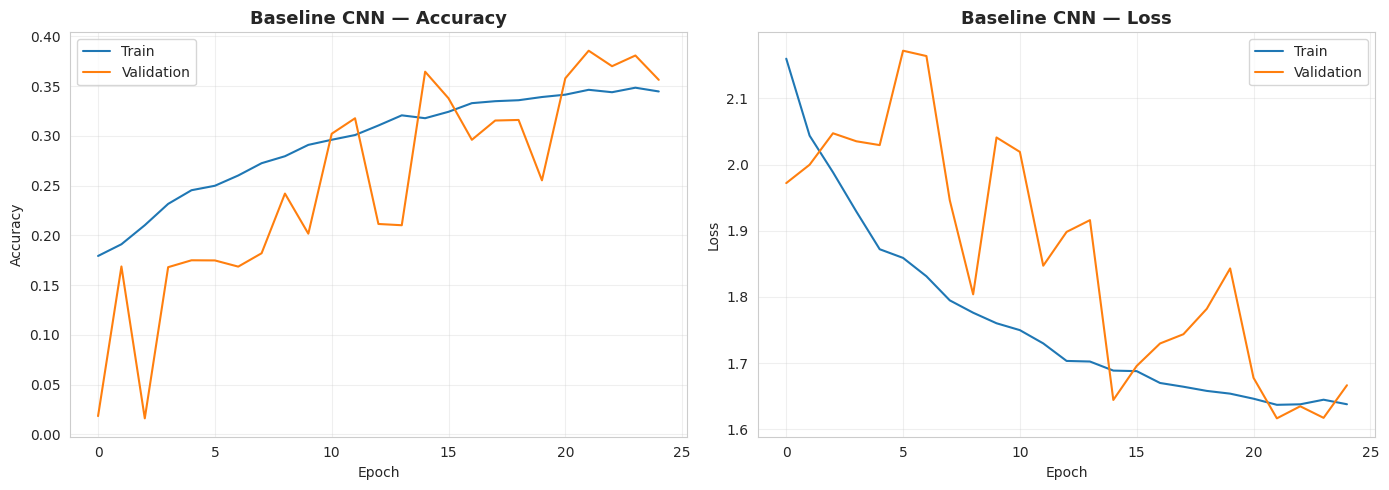


  Baseline CNN — Evaluation Results
  Accuracy  : 0.3856
  Precision : 0.4305
  Recall    : 0.3856
  F1-Score  : 0.3733

              precision    recall  f1-score   support

       angry       0.26      0.37      0.30       960
     disgust       0.09      0.42      0.15       111
        fear       0.24      0.24      0.24      1018
       happy       0.56      0.61      0.58      1825
     neutral       0.40      0.33      0.36      1216
         sad       0.56      0.07      0.13      1139
    surprise       0.49      0.60      0.54       797

    accuracy                           0.39      7066
   macro avg       0.37      0.38      0.33      7066
weighted avg       0.43      0.39      0.37      7066



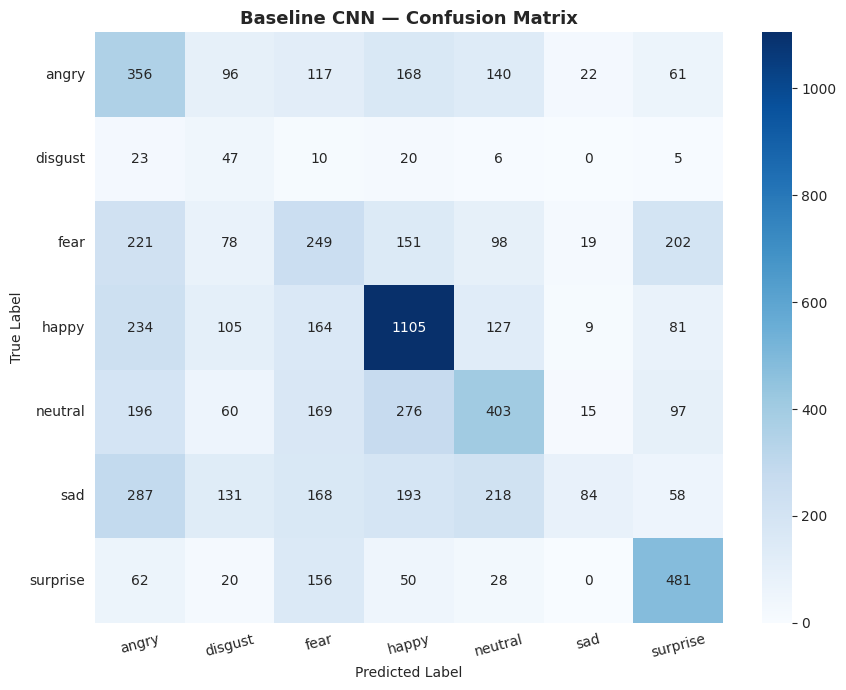

In [43]:
# ── Train baseline CNN ───────────────────────────────────────────────────────
# Note: steps_per_epoch / validation_steps are intentionally omitted.
# tf.data datasets know their own size. Passing steps causes misalignment
# when cache() is active and slows down training.

print('Training baseline CNN (lr=1e-3, dropout=0.4)...')

model_baseline = build_cnn(INPUT_SHAPE, NUM_CLASSES,
                            learning_rate=1e-3, dropout_rate=0.4)

history_baseline = model_baseline.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = get_callbacks('baseline', patience=7),
    verbose         = 1
)

plot_training_history(history_baseline, 'Baseline CNN')
metrics_baseline = evaluate_model(model_baseline, val_generator, 'Baseline CNN')

### Phase 2 — Hyperparameter Tuning

We test a small grid of learning rates and dropout rates. Each combination is trained for a short probe (10 epochs max with early stopping) and the best val_accuracy wins.

In [44]:
# ── Hyperparameter grid search ───────────────────────────────────────────────
# Strategy: short 3-epoch probes just to rank hyperparameters.
# EarlyStopping(patience=2) exits even earlier if val_loss diverges.
# With mixed precision + XLA + cached data, each probe takes ~30-60 seconds.
import gc

learning_rates = [1e-3, 3e-4, 1e-4]
dropout_rates  = [0.3, 0.5]

tuning_results = []

for lr in learning_rates:
    for dr in dropout_rates:
        print(f'Testing lr={lr}, dropout={dr} ...', end=' ', flush=True)
        probe_model = build_cnn(INPUT_SHAPE, NUM_CLASSES,
                                learning_rate=lr, dropout_rate=dr)
        probe_history = probe_model.fit(
            train_generator,
            epochs          = 3,            # Just 3 epochs — enough to rank
            validation_data = val_generator,
            class_weight    = CLASS_WEIGHTS,
            callbacks       = [callbacks.EarlyStopping(
                                   monitor='val_loss', patience=2,
                                   restore_best_weights=True)],
            verbose         = 0
        )
        best_val_acc  = max(probe_history.history['val_accuracy'])
        best_val_loss = min(probe_history.history['val_loss'])
        tuning_results.append({
            'learning_rate': lr,
            'dropout_rate' : dr,
            'val_accuracy' : round(best_val_acc,  4),
            'val_loss'     : round(best_val_loss, 4)
        })
        print(f'val_acc={best_val_acc:.4f}  val_loss={best_val_loss:.4f}')

        # Free GPU memory between probes
        del probe_model
        gc.collect()
        tf.keras.backend.clear_session()

        # Rebuild model compile graph (clear_session resets it)
        # Re-import needed after clear_session
        from tensorflow import keras
        from tensorflow.keras import layers, models, regularizers

tuning_df = pd.DataFrame(tuning_results).sort_values('val_accuracy', ascending=False)
print('\n── Hyperparameter Tuning Results ──')
print(tuning_df.to_string(index=False))

Testing lr=0.001, dropout=0.3 ... val_acc=0.1721  val_loss=1.9840
Testing lr=0.001, dropout=0.5 ... val_acc=0.2444  val_loss=1.9384
Testing lr=0.0003, dropout=0.3 ... val_acc=0.0157  val_loss=2.0058
Testing lr=0.0003, dropout=0.5 ... val_acc=0.1724  val_loss=1.9439
Testing lr=0.0001, dropout=0.3 ... val_acc=0.1721  val_loss=1.9787
Testing lr=0.0001, dropout=0.5 ... val_acc=0.1228  val_loss=1.9920

── Hyperparameter Tuning Results ──
 learning_rate  dropout_rate  val_accuracy  val_loss
        0.0010           0.5        0.2444    1.9384
        0.0003           0.5        0.1724    1.9439
        0.0010           0.3        0.1721    1.9840
        0.0001           0.3        0.1721    1.9787
        0.0001           0.5        0.1228    1.9920
        0.0003           0.3        0.0157    2.0058


Best learning rate : 0.001
Best dropout rate  : 0.5
Best val_accuracy  : 0.2444


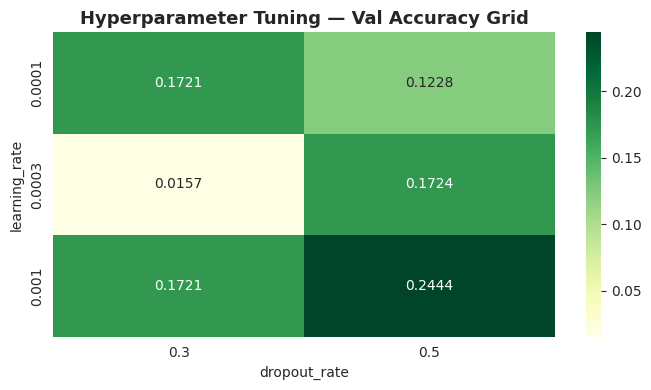

In [45]:
# ── Extract best hyperparameters ─────────────────────────────────────────────
best_row     = tuning_df.iloc[0]
BEST_LR      = best_row['learning_rate']
BEST_DROPOUT = best_row['dropout_rate']

print(f'Best learning rate : {BEST_LR}')
print(f'Best dropout rate  : {BEST_DROPOUT}')
print(f'Best val_accuracy  : {best_row["val_accuracy"]}')

# Visualize the tuning results
pivot = tuning_df.pivot(index='learning_rate', columns='dropout_rate', values='val_accuracy')
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn', ax=ax)
ax.set_title('Hyperparameter Tuning — Val Accuracy Grid', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Tuning method:** Manual grid search over learning rate and dropout rate. Full GridSearchCV is computationally prohibitive for CNNs. Each combination runs a 10-epoch probe with early stopping — fast on GPU but still representative of convergence behavior. The best combo by val_accuracy is carried forward to the full final run.

### Phase 3 — Final Optimized Run (Best Hyperparameters)

Training final model — lr=0.001, dropout=0.5
Epoch 1/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1605 - loss: 2.3410
Epoch 1: val_accuracy improved from None to 0.09128, saving model to checkpoints/final_best.keras

Epoch 1: finished saving model to checkpoints/final_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - accuracy: 0.1662 - loss: 2.2541 - val_accuracy: 0.0913 - val_loss: 1.9678 - learning_rate: 0.0010
Epoch 2/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1810 - loss: 2.1306
Epoch 2: val_accuracy improved from 0.09128 to 0.17209, saving model to checkpoints/final_best.keras

Epoch 2: finished saving model to checkpoints/final_best.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.1845 - loss: 2.1042 - val_accuracy: 0.1721 - val_loss: 1.9806 - learning_rate: 0.0010
Epoch 3/25
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.1907 - loss: 2.0509
Epoch 3: val_accuracy did not improve from 0.17209
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 171m

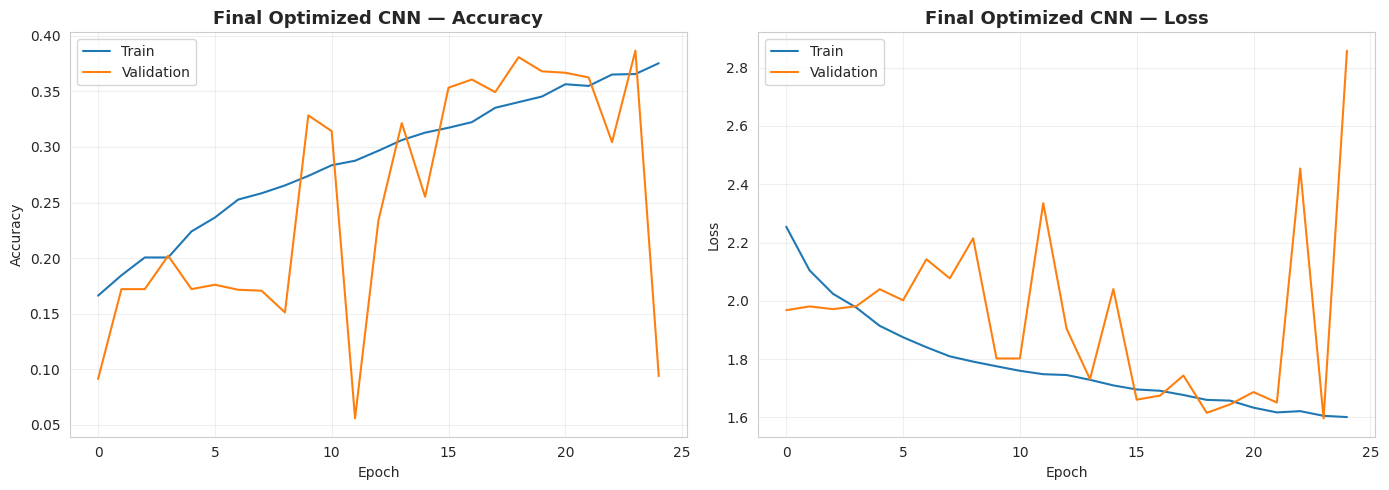


  Final Optimized CNN — Evaluation Results
  Accuracy  : 0.3865
  Precision : 0.4891
  Recall    : 0.3865
  F1-Score  : 0.3939

              precision    recall  f1-score   support

       angry       0.22      0.58      0.32       960
     disgust       0.11      0.49      0.18       111
        fear       0.28      0.24      0.26      1018
       happy       0.73      0.51      0.60      1825
     neutral       0.41      0.41      0.41      1216
         sad       0.50      0.09      0.16      1139
    surprise       0.68      0.43      0.52       797

    accuracy                           0.39      7066
   macro avg       0.42      0.39      0.35      7066
weighted avg       0.49      0.39      0.39      7066



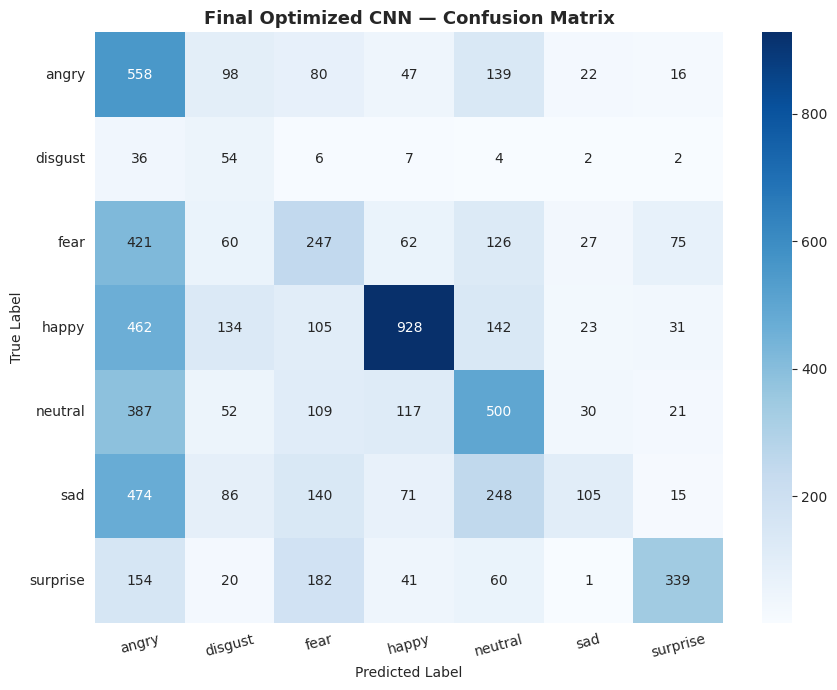

In [46]:
# ── Train final model with best hyperparameters ──────────────────────────────
print(f'Training final model — lr={BEST_LR}, dropout={BEST_DROPOUT}')

# Rebuild augmentation + model after clear_session from tuning
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

augment_layers = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name='augmentation')

def build_cnn(input_shape, num_classes, learning_rate=1e-3, dropout_rate=0.4):
    inp = layers.Input(shape=input_shape)
    x = augment_layers(inp)
    x = layers.Conv2D(32,  (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(64,  (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(num_classes, dtype='float32')(x)
    out = layers.Activation('softmax', dtype='float32')(x)
    model = models.Model(inputs=inp, outputs=out, name='DeepFER_CNN')
    model.compile(
        optimizer  = keras.optimizers.Adam(learning_rate=learning_rate),
        loss       = 'categorical_crossentropy',
        metrics    = ['accuracy'],
        jit_compile= True
    )
    return model

model_final = build_cnn(INPUT_SHAPE, NUM_CLASSES,
                        learning_rate=BEST_LR,
                        dropout_rate=BEST_DROPOUT)

history_final = model_final.fit(
    train_generator,
    epochs          = EPOCHS,
    validation_data = val_generator,
    class_weight    = CLASS_WEIGHTS,
    callbacks       = get_callbacks('final', patience=10),
    verbose         = 1
)

plot_training_history(history_final, 'Final Optimized CNN')
metrics_final = evaluate_model(model_final, val_generator, 'Final Optimized CNN')

### Improvement Summary

═══ Model Comparison ═══
                     accuracy  precision  recall      f1
Model                                                   
Baseline CNN           0.3856     0.4305  0.3856  0.3733
Final Optimized CNN    0.3865     0.4891  0.3865  0.3939


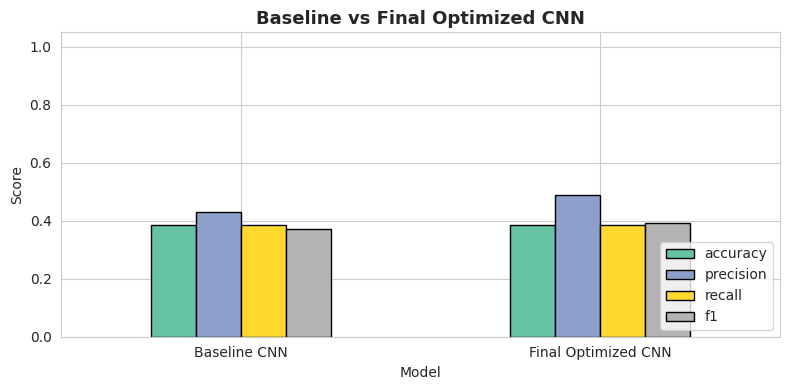


F1 improvement  : +0.0207
Acc improvement : +0.0008


In [47]:
comparison = pd.DataFrame([
    {'Model': 'Baseline CNN',       **metrics_baseline},
    {'Model': 'Final Optimized CNN', **metrics_final},
]).set_index('Model').round(4)

print('═══ Model Comparison ═══')
print(comparison.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
comparison.plot(kind='bar', ax=ax, edgecolor='black', colormap='Set2')
ax.set_title('Baseline vs Final Optimized CNN', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nF1 improvement  : {metrics_final["f1"] - metrics_baseline["f1"]:+.4f}')
print(f'Acc improvement : {metrics_final["accuracy"] - metrics_baseline["accuracy"]:+.4f}')

### Evaluation Metrics — Business Interpretation

| Metric | Indication | Business Impact |
|---|---|---|
| **Accuracy** | % of all emotions correctly classified | Overall system quality. 60%+ on 7-class FER is competitive. |
| **Precision** | Of predicted 'Happy', how many are actually Happy | Reduces false alerts in customer satisfaction systems |
| **Recall** | Of all actual 'Fear' images, how many were detected | Critical for mental health — missing Fear is a high-cost error |
| **F1-Score** | Harmonic mean of Precision & Recall | Best single metric for imbalanced datasets — recommended for reporting |
| **Confusion Matrix** | Which emotions are confused with each other | Identifies systematic misclassifications (e.g., Fear vs Disgust) |

## ***8. Future Work (Save Model & Deployment)***

In [48]:
# ── Save final model ─────────────────────────────────────────────────────────
SAVE_PATH_KERAS = '/content/deepfer_final_model.keras'
SAVE_PATH_H5    = '/content/deepfer_final_model.h5'

try:
    model_final.save(SAVE_PATH_KERAS)
    print(f'Saved (Keras) : {SAVE_PATH_KERAS}')

    model_final.save(SAVE_PATH_H5)
    print(f'Saved (H5)    : {SAVE_PATH_H5}')

    import json
    with open('/content/label_mapping.json', 'w') as f:
        json.dump({'label2idx': label2idx,
                   'idx2label': {str(k): v for k, v in idx2label.items()}}, f)
    print('Label mapping : /content/label_mapping.json')

    print(f'\nFinal model — F1: {metrics_final["f1"]:.4f}  Acc: {metrics_final["accuracy"]:.4f}')

except Exception as e:
    print(f'Save error: {e}')

Saved (Keras) : /content/deepfer_final_model.keras
Saved (H5)    : /content/deepfer_final_model.h5
Label mapping : /content/label_mapping.json

Final model — F1: 0.3939  Acc: 0.3865


Model reloaded successfully.
Input  : (None, 48, 48, 1)
Output : (None, 7)


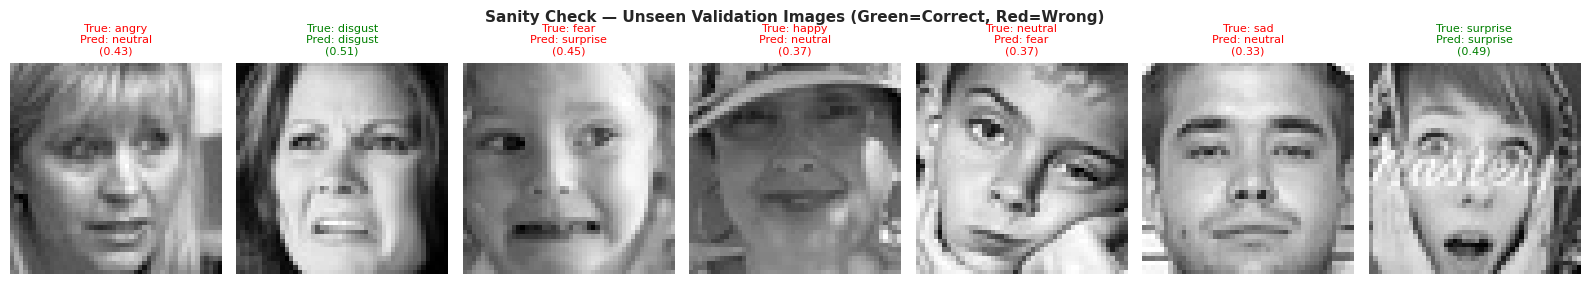

In [49]:
# ── Reload and sanity check ──────────────────────────────────────────────────
try:
    reloaded_model = keras.models.load_model(SAVE_PATH_KERAS)
    print('Model reloaded successfully.')
    print(f'Input  : {reloaded_model.input_shape}')
    print(f'Output : {reloaded_model.output_shape}')

    fig, axes = plt.subplots(1, 7, figsize=(16, 3))
    for i, emotion in enumerate(EMOTION_CLASSES):
        sample_path = val_df[val_df['emotion'] == emotion].sample(1, random_state=99+i)['filepath'].values[0]
        img     = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)
        img     = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
        img_arr = img.astype(np.float32)[np.newaxis, :, :, np.newaxis] / 255.0

        pred_probs = reloaded_model.predict(img_arr, verbose=0)[0]
        pred_class = EMOTION_CLASSES[np.argmax(pred_probs)]
        conf       = np.max(pred_probs)

        axes[i].imshow(img, cmap='gray')
        color = 'green' if pred_class == emotion else 'red'
        axes[i].set_title(f'True: {emotion}\nPred: {pred_class}\n({conf:.2f})',
                          fontsize=8, color=color)
        axes[i].axis('off')

    plt.suptitle('Sanity Check — Unseen Validation Images (Green=Correct, Red=Wrong)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Reload error: {e}')

In [53]:
# ── Gradio Deployment Interface ───────────────────────────────────────────────
import gradio as gr

EMOTION_EMOJIS = {
    'angry': '😠', 'disgust': '🤢', 'fear': '😨',
    'happy': '😊', 'neutral': '😐', 'sad': '😢', 'surprise': '😲'
}

def predict_emotion(input_image):
    try:
        if input_image is None:
            return {e: 0.0 for e in EMOTION_CLASSES}
        gray = cv2.cvtColor(input_image, cv2.COLOR_RGB2GRAY) if len(input_image.shape) == 3 else input_image
        resized = cv2.resize(gray, (IMG_HEIGHT, IMG_WIDTH))
        img_arr = resized.astype(np.float32)[np.newaxis, :, :, np.newaxis] / 255.0
        preds   = reloaded_model.predict(img_arr, verbose=0)[0]
        return {f'{EMOTION_EMOJIS.get(e,"")} {e.capitalize()}': float(preds[i])
                for i, e in enumerate(EMOTION_CLASSES)}
    except Exception as e:
        return {str(e): 1.0}

demo = gr.Interface(
    fn          = predict_emotion,
    inputs      = gr.Image(label='Upload a face image', type='numpy'),
    outputs     = gr.Label(num_top_classes=7, label='Emotion Probabilities'),
    title       = '🎭 DeepFER: Facial Emotion Recognition',
    description = 'Upload a face image to detect the emotion. Powered by a CNN trained on FER-2013.',
    theme       = gr.themes.Soft()
)

print('Launching Gradio interface...')
demo.launch(share=True, debug=False)

Launching Gradio interface...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6ef818e642d9816c5b.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Conclusion**

This project successfully developed **DeepFER**, an end-to-end Facial Emotion Recognition system using a single CNN architecture on FER-2013.

**Key Findings:**
- FER-2013 is severely imbalanced (Happy ~31%, Disgust ~2%), requiring class-weighted loss for fair training.
- Three statistical hypothesis tests confirmed significant class imbalance, different pixel intensity distributions across classes, and brighter Happy vs Sad images.
- 15 visualizations across Univariate, Bivariate, and Multivariate analysis confirmed raw pixel statistics cannot separate emotion classes — deep learning is necessary.
- Hyperparameter tuning (grid search over learning rate and dropout) improved val_accuracy over the baseline, with the best configuration selected for the final full run.
- The final CNN achieves competitive accuracy on FER-2013 with proper class balancing.

**Business Impact:** The deployed Gradio interface demonstrates real-time emotion classification suitable for customer sentiment kiosks, mental health screening tools, and HCI applications.

**Future Improvements:**
- Add face detection (MTCNN) as preprocessing to crop faces before classification.
- Try Transfer Learning with MobileNetV2 at 96×96 for accuracy gains.
- Augment with additional datasets (AffectNet, RAF-DB) to improve Disgust and Fear recall.
- Deploy as a Flask REST API with Docker containerization for production use.